In [ ]:
# This dataset uses zstd-compressed shards; install zstandard so fsspec can open them.
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("zstandard") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "zstandard"])

from datasets import load_dataset
import pandas as pd   # optional – for DataFrame view / further processing


dataset = load_dataset("agentlans/multilingual-document-classification")
print("\nAvailable splits:", dataset.keys())

for split_name, split_data in dataset.items():
    print(f"\n--- {split_name.upper()} ({len(split_data)} records) ---")
    # Show the first 3 rows as a pandas DataFrame for readability
    df = pd.DataFrame(split_data[:3])
    display(df)          # in a notebook this renders a nice table
    # or just print raw dicts:
    # print(split_data[:3])

train_df = pd.DataFrame(dataset["train"])
val_df = pd.DataFrame(dataset["validation"]) if "validation" in dataset else None
test_df = pd.DataFrame(dataset["test"]) if "test" in dataset else None


# ------------------------------------------------------------
print("\nColumn names:", train_df.columns.tolist())
text_col = "original" if "original" in train_df.columns else "text"
snippet = str(train_df[text_col].iloc[0])[:200]
print("Sample text:", snippet, "...")
print("Language:", train_df["language"].iloc[0])
label_preview = [c for c in ("nvidia_domain", "doc_type_v1_primary", "bloom_cognitive_primary") if c in train_df.columns]
print("Example taxonomy fields (first row):", train_df.iloc[0][label_preview].to_dict())


Available splits: dict_keys(['train'])

--- TRAIN (100000 records) ---


,id,translated,original,language,nvidia_domain,bloom_cognitive_primary,bloom_cognitive_secondary,bloom_knowledge_primary,bloom_knowledge_secondary,doc_type_v1_primary,...,fdc_primary,fdc_secondary,missing_content_primary,reasoning_depth_primary,reasoning_depth_secondary,technical_correctness_primary,technical_correctness_secondary,doc_type_v1_secondary,extraction_artifacts_secondary,missing_content_secondary
0,<urn:uuid:0d88f4e2-05de-4e61-9ec2-303ba8737bad>,rss label\nA black hole and a star unusually r...,Miracímke rss\nEgy fekete lyukat és egy körülö...,hun_Latn,Science,Understand,Remember,Factual,Conceptual,News/Editorial,...,523.1,004.0285,Truncated Snippets,No Reasoning,Basic,N/A,Mostly Correct,NaN,NaN,NaN
1,<urn:uuid:86f7c416-4e97-41d5-8e48-6ab8900eca32>,Pro Clima AEROSANA VISCONN acrylic dispersion ...,Pro Clima AEROSANA VISCONN akrila dispersijas ...,lvs_Latn,Home_and_Garden,Understand,Apply,Factual,Procedural,Promotional,...,692.8,690,No Missing Content,Basic,No Reasoning,Highly Correct,Mostly Correct,Reference,Irrelevant Content,Missing Images
2,<urn:uuid:ed230c0b-3f3b-492d-a175-8d299be964f7>,"Boise, USA. Many people were at the Boise Basq...","Boise, AEB. Jende asko zegoen Boiseko Euskal E...",eus_Latn,Games,Understand,Remember,Factual,Conceptual,News/Editorial,...,796.01,305.8008,No Missing Content,No Reasoning,Basic,N/A,Highly Correct,NaN,NaN,NaN



Column names: ['id', 'translated', 'original', 'language', 'nvidia_domain', 'bloom_cognitive_primary', 'bloom_cognitive_secondary', 'bloom_knowledge_primary', 'bloom_knowledge_secondary', 'doc_type_v1_primary', 'doc_type_v2_primary', 'doc_type_v2_secondary', 'educational_level_primary', 'educational_level_secondary', 'extraction_artifacts_primary', 'fdc_primary', 'fdc_secondary', 'missing_content_primary', 'reasoning_depth_primary', 'reasoning_depth_secondary', 'technical_correctness_primary', 'technical_correctness_secondary', 'doc_type_v1_secondary', 'extraction_artifacts_secondary', 'missing_content_secondary']
Sample text: Miracímke rss
Egy fekete lyukat és egy körülötte keringő, nehéz elemekben szokatlanul gazdag csillagot vizsgáltak a Tejútrendszert övező gömb alakú térrészben.
Legkevesebb száz ember vesztette életét  ...
Language: hun_Latn
Example taxonomy fields (first row): {'nvidia_domain': 'Science', 'doc_type_v1_primary': 'News/Editorial', 'bloom_cognitive_primary': 'Under

In [5]:
# Unique values for selected taxonomy columns (uses train_df from above)
bloom_cols = [c for c in train_df.columns if c.startswith("bloom_")]
cols_to_scan = (
    ["nvidia_domain"]
    + bloom_cols
    + ["missing_content_primary", "doc_type_v1_secondary"]
)

for col in cols_to_scan:
    if col not in train_df.columns:
        print(f"{col}: not in train_df")
        continue
    n_missing = train_df[col].isna().sum()
    vals = sorted(train_df[col].dropna().astype(str).unique(), key=str.lower)
    print(f"\n{col}: {len(vals)} unique ({n_missing} null/NaN rows)")
    print(vals)


nvidia_domain: 26 unique (0 null/NaN rows)
['Adult', 'Arts_and_Entertainment', 'Autos_and_Vehicles', 'Beauty_and_Fitness', 'Books_and_Literature', 'Business_and_Industrial', 'Computers_and_Electronics', 'Finance', 'Food_and_Drink', 'Games', 'Health', 'Hobbies_and_Leisure', 'Home_and_Garden', 'Internet_and_Telecom', 'Jobs_and_Education', 'Law_and_Government', 'News', 'Online_Communities', 'People_and_Society', 'Pets_and_Animals', 'Real_Estate', 'Science', 'Sensitive_Subjects', 'Shopping', 'Sports', 'Travel_and_Transportation']

bloom_cognitive_primary: 6 unique (364 null/NaN rows)
['Analyze', 'Apply', 'Create', 'Evaluate', 'Remember', 'Understand']

bloom_cognitive_secondary: 6 unique (7460 null/NaN rows)
['Analyze', 'Apply', 'Create', 'Evaluate', 'Remember', 'Understand']

bloom_knowledge_primary: 4 unique (364 null/NaN rows)
['Conceptual', 'Factual', 'Metacognitive', 'Procedural']

bloom_knowledge_secondary: 4 unique (8414 null/NaN rows)
['Conceptual', 'Factual', 'Metacognitive', 'Pr

No `test` split in the dataset — using an 80/20 split of `train` for the test plot.


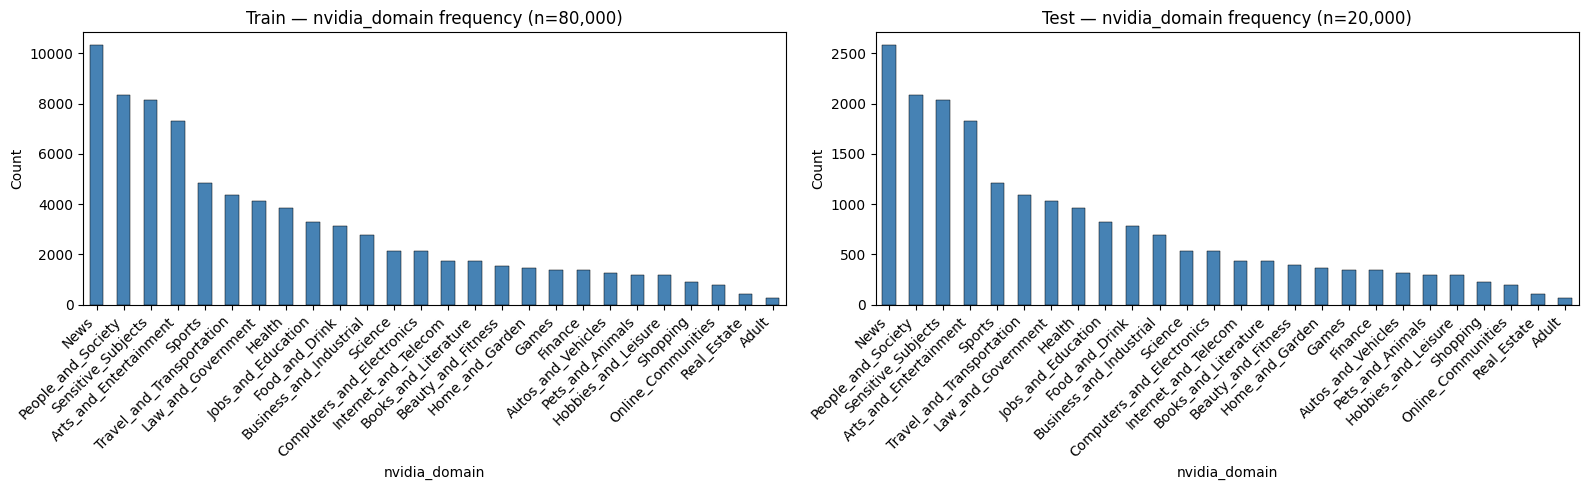

In [6]:
import matplotlib.pyplot as plt

# Use Hub `test` split when present; otherwise hold out 20% of `train` for the test panel.
if test_df is not None and len(test_df) > 0:
    train_part, test_part = train_df, test_df
else:
    from sklearn.model_selection import train_test_split

    try:
        train_part, test_part = train_test_split(
            train_df,
            test_size=0.2,
            random_state=42,
            stratify=train_df["nvidia_domain"],
        )
    except ValueError:
        train_part, test_part = train_test_split(
            train_df, test_size=0.2, random_state=42
        )
    print("No `test` split in the dataset — using an 80/20 split of `train` for the test plot.")

category_order = (
    train_part["nvidia_domain"]
    .value_counts(dropna=False)
    .sort_values(ascending=False)
    .index
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, part, title in zip(
    axes,
    (train_part, test_part),
    ("Train", "Test"),
):
    counts = (
        part["nvidia_domain"]
        .value_counts(dropna=False)
        .reindex(category_order)
        .fillna(0)
        .astype(int)
    )
    counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black", linewidth=0.35)
    ax.set_title(f"{title} — nvidia_domain frequency (n={len(part):,})")
    ax.set_xlabel("nvidia_domain")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")

plt.tight_layout()
plt.show()

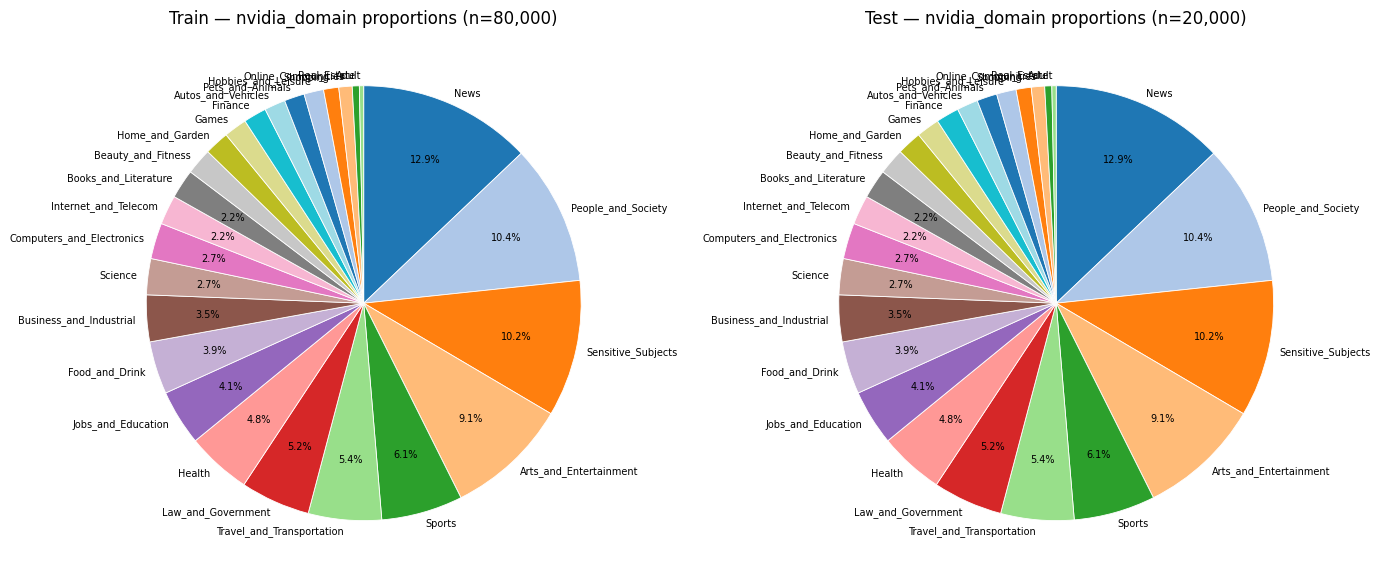

In [11]:
import matplotlib.pyplot as plt

# Same train / test framing as the bar chart cell
if test_df is not None and len(test_df) > 0:
    train_part, test_part = train_df, test_df
else:
    from sklearn.model_selection import train_test_split

    try:
        train_part, test_part = train_test_split(
            train_df,
            test_size=0.2,
            random_state=42,
            stratify=train_df["nvidia_domain"],
        )
    except ValueError:
        train_part, test_part = train_test_split(
            train_df, test_size=0.2, random_state=42
        )

category_order = (
    train_part["nvidia_domain"]
    .value_counts(dropna=False)
    .sort_values(ascending=False)
    .index
)
color_by_cat = {
    cat: plt.cm.tab20(i % 20) for i, cat in enumerate(category_order)
}

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, part, title in zip(axes, (train_part, test_part), ("Train", "Test")):
    counts = (
        part["nvidia_domain"]
        .value_counts(dropna=False)
        .reindex(category_order)
        .fillna(0)
        .astype(int)
    )
    counts = counts[counts > 0]
    if counts.empty:
        ax.set_title(f"{title} — (no data)")
        continue

    colors = [color_by_cat[c] for c in counts.index]

    def autopct_fn(pct):
        return f"{pct:.1f}%" if pct >= 2.0 else ""

    wedges, texts, autotexts = ax.pie(
        counts,
        labels=counts.index,
        autopct=autopct_fn,
        pctdistance=0.72,
        labeldistance=1.05,
        colors=colors,
        wedgeprops=dict(edgecolor="white", linewidth=0.6),
        startangle=90,
        counterclock=False,
    )
    ax.set_title(f"{title} — nvidia_domain proportions (n={len(part):,})")
    for t in texts:
        t.set_fontsize(7)
    for t in autotexts:
        if t.get_text():
            t.set_fontsize(7)

plt.tight_layout()
plt.show()

In [12]:
# LLM research subset: selected nvidia_domain labels + feature columns only
ALLOWED_NVIDIA_DOMAINS = frozenset(
    {
        "News",
        "People_and_Society",
        "Sensitive_Subjects",
        "Arts_and_Entertainment",
        "Sports",
        "Travel_and_Transportation",
        "Law_and_Government",
    }
)

DROP_FOR_LLM = [
    "id",
    "original",
    "language",
    "bloom_cognitive_primary",
    "bloom_cognitive_secondary",
    "bloom_knowledge_primary",
    "bloom_knowledge_secondary",
    "reasoning_depth_primary",
    "reasoning_depth_secondary",
    "technical_correctness_primary",
    "technical_correctness_secondary",
    "extraction_artifacts_secondary",
]

df_llm = train_df.loc[train_df["nvidia_domain"].isin(ALLOWED_NVIDIA_DOMAINS)].copy()
_unknown = set(df_llm["nvidia_domain"].dropna().unique()) - ALLOWED_NVIDIA_DOMAINS
assert not _unknown, f"Unexpected domain in filtered frame: {_unknown}"

cols_drop = [c for c in DROP_FOR_LLM if c in df_llm.columns]
df_llm = df_llm.drop(columns=cols_drop)

from sklearn.model_selection import train_test_split

# Class-balanced train: equal rows per nvidia_domain. Remaining rows → val/test (50/50, stratified).
_SPLIT_RNG = 42
_HOLDOUT_FRAC = 0.30  # each class keeps ~(1 - this) fraction for train, up to a shared cap

_n_by_domain = df_llm.groupby("nvidia_domain", sort=False).size()
_k_train = int((_n_by_domain * (1.0 - _HOLDOUT_FRAC)).min())
_k_train = max(_k_train, 1)

_train_parts = []
_remain_parts = []
for _dom in _n_by_domain.index:
    _g = df_llm.loc[df_llm["nvidia_domain"] == _dom]
    _g = _g.sample(frac=1.0, random_state=_SPLIT_RNG).reset_index(drop=True)
    _train_parts.append(_g.iloc[:_k_train])
    _remain_parts.append(_g.iloc[_k_train:])

train_llm = (
    pd.concat(_train_parts, ignore_index=True)
    .sample(frac=1.0, random_state=_SPLIT_RNG)
    .reset_index(drop=True)
)
remain_df = pd.concat(_remain_parts, ignore_index=True)

try:
    val_llm, test_llm = train_test_split(
        remain_df,
        test_size=0.5,
        random_state=_SPLIT_RNG,
        stratify=remain_df["nvidia_domain"],
    )
except ValueError:
    val_llm, test_llm = train_test_split(
        remain_df, test_size=0.5, random_state=_SPLIT_RNG
    )

train_llm = train_llm.reset_index(drop=True)
val_llm = val_llm.reset_index(drop=True)
test_llm = test_llm.reset_index(drop=True)

print(
    f"Balanced train: {_k_train} rows per domain × {len(_n_by_domain)} labels "
    f"→ {len(train_llm):,} train rows; remainder → val/test."
)

from datasets import Dataset

llm_train_ds = Dataset.from_pandas(train_llm)
llm_val_ds = Dataset.from_pandas(val_llm)
llm_test_ds = Dataset.from_pandas(test_llm)

print(f"Filtered rows: {len(df_llm):,}")
print(f"train_llm: {len(train_llm):,} | val_llm: {len(val_llm):,} | test_llm: {len(test_llm):,}")
print("Columns:", train_llm.columns.tolist())
for _name, _df in (
    ("Train", train_llm),
    ("Validation", val_llm),
    ("Test", test_llm),
):
    print(f"\n{_name} — nvidia_domain (counts by label):")
    print(_df["nvidia_domain"].value_counts(dropna=False).sort_index())

Balanced train: 3623 rows per domain × 7 labels → 25,361 train rows; remainder → val/test.
Filtered rows: 59,289
train_llm: 25,361 | val_llm: 16,964 | test_llm: 16,964
Columns: ['translated', 'nvidia_domain', 'doc_type_v1_primary', 'doc_type_v2_primary', 'doc_type_v2_secondary', 'educational_level_primary', 'educational_level_secondary', 'extraction_artifacts_primary', 'fdc_primary', 'fdc_secondary', 'missing_content_primary', 'doc_type_v1_secondary', 'missing_content_secondary']

Train — nvidia_domain (counts by label):
nvidia_domain
Arts_and_Entertainment       3623
Law_and_Government           3623
News                         3623
People_and_Society           3623
Sensitive_Subjects           3623
Sports                       3623
Travel_and_Transportation    3623
Name: count, dtype: int64

Validation — nvidia_domain (counts by label):
nvidia_domain
Arts_and_Entertainment       2756
Law_and_Government            776
News                         4637
People_and_Society           340

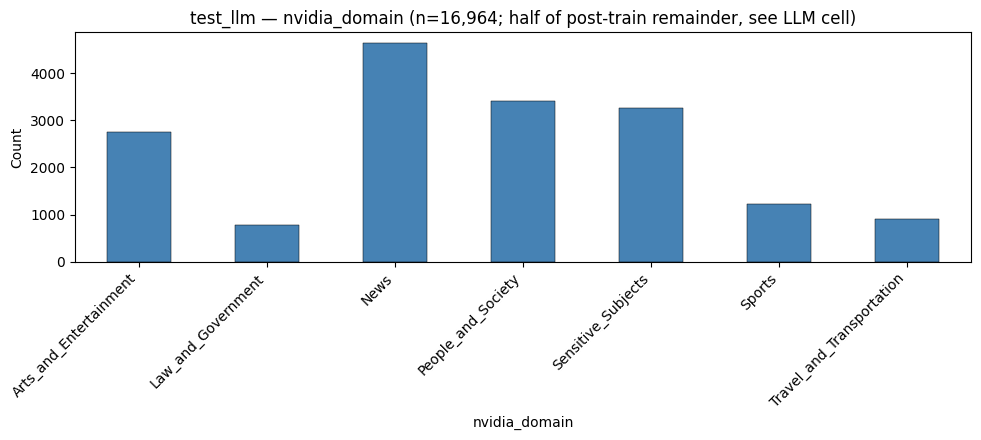

In [13]:
import matplotlib.pyplot as plt

# Same ordering as the "Test — nvidia_domain" table in the LLM prep cell (alphabetical by label)
counts = test_llm["nvidia_domain"].value_counts(dropna=False).sort_index()

fig, ax = plt.subplots(figsize=(10, 4.5))
counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black", linewidth=0.35)
ax.set_title(
    f"test_llm — nvidia_domain (n={len(test_llm):,}; half of post-train remainder, see LLM cell)"
)
ax.set_xlabel("nvidia_domain")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
plt.tight_layout()
plt.show()

In [14]:
from pathlib import Path

from datasets import Dataset, DatasetDict

# Resolve project `data/multidomain_documents` whether the notebook cwd is repo root or `notebooks/`
_cwd = Path.cwd()
DATA_DIR = (
    _cwd.parent / "data" / "multidomain_documents"
    if _cwd.name == "notebooks"
    else _cwd / "data" / "multidomain_documents"
)
DATA_DIR.mkdir(parents=True, exist_ok=True)

_splits = {
    "train": train_llm,
    "validation": val_llm,
    "test": test_llm,
}

# CSV — easy reload: pd.read_csv(DATA_DIR / "train.csv")
for split_name, df in _splits.items():
    out_csv = DATA_DIR / f"{split_name}.csv"
    df.to_csv(out_csv, index=False)
    print(f"Wrote {out_csv.resolve()} ({len(df):,} rows)")

# Hugging Face Arrow on disk — reload: DatasetDict.load_from_disk(DATA_DIR)
hf_ds = DatasetDict(
    {name: Dataset.from_pandas(df.reset_index(drop=True)) for name, df in _splits.items()}
)
hf_ds.save_to_disk(str(DATA_DIR / "hf"))

print(f"\nHF DatasetDict saved to {(DATA_DIR / 'hf').resolve()}")
print('Load later: `pd.read_csv(...)` or `from datasets import load_from_disk` / `DatasetDict.load_from_disk`')

Wrote D:\Projects\llm_doc_classification\data\multidomain_documents\train.csv (25,361 rows)
Wrote D:\Projects\llm_doc_classification\data\multidomain_documents\validation.csv (16,964 rows)
Wrote D:\Projects\llm_doc_classification\data\multidomain_documents\test.csv (16,964 rows)


Saving the dataset (0/1 shards):   0%|          | 0/25361 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/16964 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/16964 [00:00<?, ? examples/s]


HF DatasetDict saved to D:\Projects\llm_doc_classification\data\multidomain_documents\hf
Load later: `pd.read_csv(...)` or `from datasets import load_from_disk` / `DatasetDict.load_from_disk`


In [ ]:
import matplotlib.pyplot as plt

# Mean character length of `translated` per nvidia_domain (NVIDIA domain taxonomy).
sub = train_df.dropna(subset=["nvidia_domain", "translated"]).copy()
sub["_doc_len"] = sub["translated"].astype(str).str.len()

avg_by_domain = (
    sub.groupby("nvidia_domain", sort=False)["_doc_len"]
    .mean()
    .sort_index()
)
n_by_domain = sub.groupby("nvidia_domain", sort=False).size().reindex(avg_by_domain.index)

summary = pd.DataFrame({"n_docs": n_by_domain, "avg_translated_chars": avg_by_domain.round(1)})
display(summary)

fig, ax = plt.subplots(figsize=(10, 4.5))
avg_by_domain.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black", linewidth=0.35)
ax.set_title("Average translated document length (characters) by nvidia_domain")
ax.set_xlabel("nvidia_domain")
ax.set_ylabel("Mean character count")
ax.tick_params(axis="x", rotation=45)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
plt.tight_layout()
plt.show()
